# 04. 생존 분석 (Survival Analysis)

`03_classification`은 "관측 종료 시점에 살았나/죽었나"라는 **한 순간**만 예측했다. 하지만 실무의 질문은 시간축 위에 있다.

> "이 묘목은 *언제쯤* 위험해지는가?", "30일 뒤 생존 확률은?", "관리를 언제 집중해야 하나?"

이런 질문에 답하려면 **시간에 따른 생존 확률 곡선**을 예측해야 한다. 이것이 생존 분석이다.

### 생존 분석이 분류보다 나은 점
- **중도절단(censoring) 활용**: 분류에서 버렸던 수확 개체(704그루)도 "그 시점까지 살아있었다"는 정보로 쓴다.
- **시간축 예측**: 특정 시점이 아니라 전체 시간에 걸친 생존 곡선을 얻는다.

### 데이터 구성
- `duration` = 사건까지의 시간 (`Time`)
- `event` = 사망(1) / 중도절단(0, 수확·생존)

여기서 `Time`을 쓰는 것은 정당하다 — 분류에서는 `Time`이 *피처*(누수)였지만, 생존 분석에서는 *예측 대상*이기 때문이다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import platform

if platform.system() == "Windows":
    rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    rcParams["font.family"] = "AppleGothic"
rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=rcParams["font.family"])

from sklearn.model_selection import train_test_split
RANDOM_STATE = 42

surv = pd.read_csv("../data/processed/surv_dataset.csv")
print("shape:", surv.shape)
print("event(사망=1, 중도절단=0):", surv["event"].value_counts().to_dict())
surv.head()

shape: (2782, 15)
event(사망=1, 중도절단=0): {1: 1587, 0: 1195}


,Species,Light_ISF,Light_Cat,Soil,Sterile,Conspecific,Myco,SoilMyco,AMF,EMF,Phenolics,Lignin,NSC,duration,event
0,0,0.106,2,3,0,1,0,0,22.00,0.00,0.79,13.86,12.15,14.0,1
1,2,0.106,2,5,0,1,1,1,15.82,31.07,6.54,20.52,19.29,115.5,0
2,3,0.106,2,3,0,1,1,0,24.45,28.19,4.71,24.74,15.01,63.0,1
3,0,0.080,2,3,0,1,0,0,22.23,0.00,0.64,14.29,12.36,14.0,1
4,0,0.060,1,3,0,1,0,0,21.15,0.00,0.77,10.85,11.20,14.0,1


## 1. Kaplan-Meier — 전체 생존 곡선

먼저 모델 없이, 데이터가 보여주는 전체 생존 곡선을 그린다. Kaplan-Meier는 중도절단을 반영해 시간별 생존 확률을 추정한다.

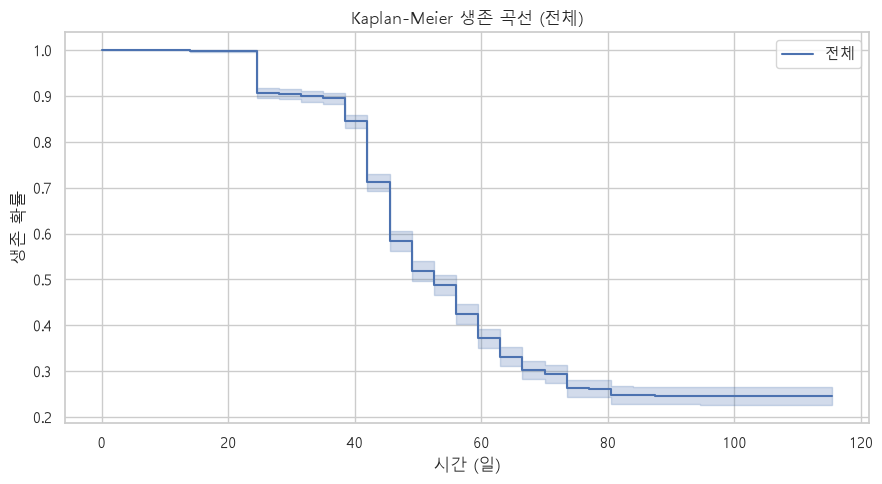

중앙 생존 시간: 52.5 일


In [2]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(surv["duration"], surv["event"], label="전체")

fig, ax = plt.subplots(figsize=(9, 5))
kmf.plot_survival_function(ax=ax)
ax.set_title("Kaplan-Meier 생존 곡선 (전체)")
ax.set_xlabel("시간 (일)")
ax.set_ylabel("생존 확률")
plt.tight_layout()
plt.show()

print(f"중앙 생존 시간: {kmf.median_survival_time_} 일")

초기(특히 ~50일)에 생존 확률이 가파르게 떨어진다. 초반이 묘목에게 가장 위험한 구간이라는 뜻이다.

### 균근 타입별 생존 곡선

`01_EDA`에서 가장 강했던 요인 `Myco`(균근 타입)로 나눠 그려본다.

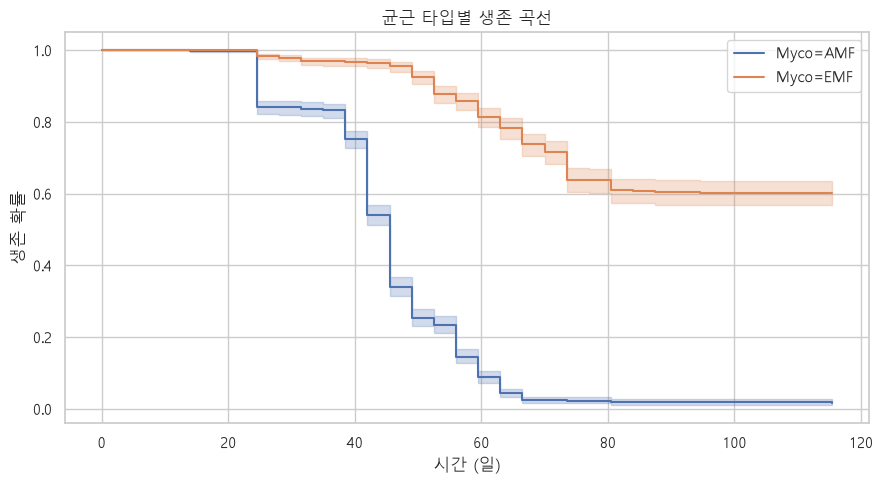

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
for val, label in [(0, "AMF"), (1, "EMF")]:
    mask = surv["Myco"] == val
    kmf.fit(surv.loc[mask, "duration"], surv.loc[mask, "event"], label=f"Myco={label}")
    kmf.plot_survival_function(ax=ax)
ax.set_title("균근 타입별 생존 곡선")
ax.set_xlabel("시간 (일)")
ax.set_ylabel("생존 확률")
plt.tight_layout()
plt.show()

EMF 균근과 공생하는 묘목의 생존 곡선이 뚜렷하게 위에 있다. 분류에서 본 "EMF가 생존율을 크게 높인다"는 결론이 시간축에서도 일관되게 확인된다.

## 2. Cox 비례위험 모델 (lifelines)

Cox 모델은 각 변수가 사망 위험(hazard)에 미치는 영향을 **위험비(hazard ratio)** 로 해석할 수 있게 해준다.
- HR > 1: 위험 증가 (생존에 불리)
- HR < 1: 위험 감소 (생존에 유리)

In [4]:
from lifelines import CoxPHFitter

train, test = train_test_split(
    surv, test_size=0.2, random_state=RANDOM_STATE, stratify=surv["event"]
)

cph = CoxPHFitter(penalizer=0.1)   # 약한 정규화로 안정적 추정
cph.fit(train, duration_col="duration", event_col="event")

cox_cindex = cph.score(test, scoring_method="concordance_index")
print(f"Cox C-index (test): {cox_cindex:.4f}")

Cox C-index (test): 0.7462


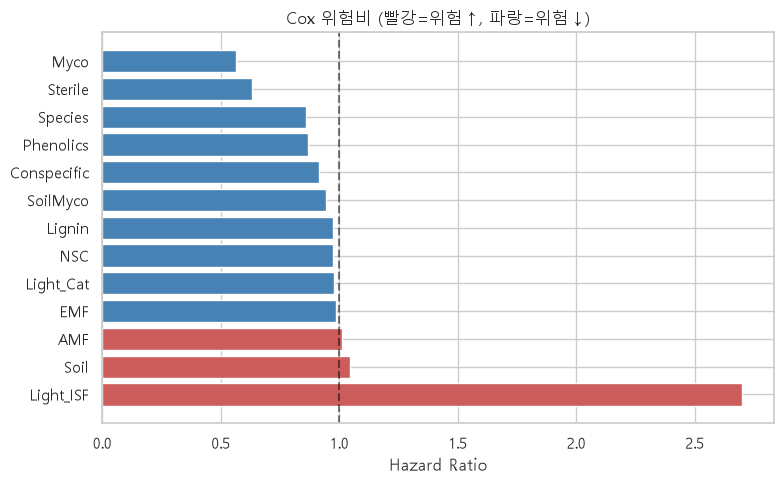

             hazard_ratio
covariate                
Light_ISF           2.700
Soil                1.046
AMF                 1.010
EMF                 0.988
Light_Cat           0.980
NSC                 0.974
Lignin              0.972
SoilMyco            0.943
Conspecific         0.915
Phenolics           0.869
Species             0.858
Sterile             0.631
Myco                0.565


In [5]:
hr = pd.DataFrame({
    "hazard_ratio": np.exp(cph.params_),
}).sort_values("hazard_ratio", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["indianred" if v > 1 else "steelblue" for v in hr["hazard_ratio"]]
ax.barh(hr.index, hr["hazard_ratio"], color=colors)
ax.axvline(1.0, color="black", linestyle="--", alpha=0.5)
ax.set_title("Cox 위험비 (빨강=위험↑, 파랑=위험↓)")
ax.set_xlabel("Hazard Ratio")
plt.tight_layout()
plt.show()

print(hr.round(3).to_string())

`Myco`, `Sterile`, `Species`의 위험비가 1보다 뚜렷하게 낮다 → 생존에 유리하게 작용. `Light_ISF`는 위험비가 높게 나오는데, 이는 다른 변수와의 상호작용/척도 영향이 섞인 것으로 단독 해석은 주의가 필요하다.

## 3. Random Survival Forest (scikit-survival)

Cox는 "비례위험"이라는 선형 가정을 둔다. RSF는 트리 기반으로 비선형 관계와 상호작용을 잡아낼 수 있다.

In [6]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored

feat = [c for c in surv.columns if c not in ("duration", "event")]
X_train, X_test = train[feat], test[feat]
y_train = Surv.from_arrays(event=train["event"].astype(bool), time=train["duration"])

rsf = RandomSurvivalForest(
    n_estimators=200, min_samples_leaf=15, random_state=RANDOM_STATE, n_jobs=-1
)
rsf.fit(X_train, y_train)

risk = rsf.predict(X_test)
rsf_cindex = concordance_index_censored(
    test["event"].astype(bool).values, test["duration"].values, risk
)[0]
print(f"RSF C-index (test): {rsf_cindex:.4f}")

RSF C-index (test): 0.7623


## 4. 모델 비교

C-index(일치도 지수)로 두 생존 모델을 비교한다. 0.5=무작위, 1.0=완벽.

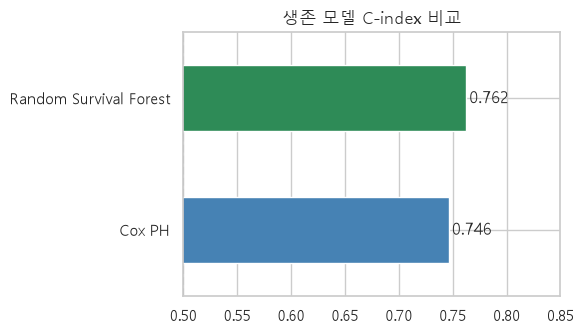

,C-index
Cox PH,0.7462
Random Survival Forest,0.7623


In [7]:
cmp = pd.DataFrame({
    "C-index": [cox_cindex, rsf_cindex]
}, index=["Cox PH", "Random Survival Forest"]).round(4)

fig, ax = plt.subplots(figsize=(6, 3.5))
cmp["C-index"].plot(kind="barh", ax=ax, color=["steelblue", "seagreen"])
ax.set_xlim(0.5, 0.85)
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5)
ax.set_title("생존 모델 C-index 비교")
for i, v in enumerate(cmp["C-index"]):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

cmp

**RSF가 Cox보다 조금 더 높다** (약 0.76 vs 0.75). 비선형 관계를 잡는 트리 기반 모델이 이 데이터에 조금 더 잘 맞았다.

두 모델 모두 C-index 0.75 안팎으로, "무작위(0.5)보다 확실히 낫고 실용적으로 쓸 만한" 수준이다.

## 5. 개체별 생존 곡선 예측

RSF는 개별 묘목마다 생존 곡선을 예측할 수 있다. 테스트셋에서 위험도가 가장 높은/낮은 개체의 곡선을 비교해본다.

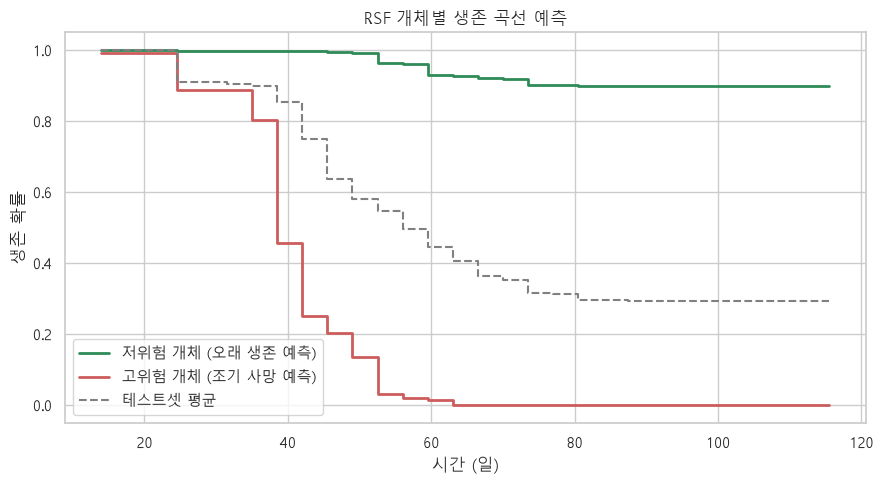

In [8]:
surv_funcs = rsf.predict_survival_function(X_test)
times = rsf.unique_times_

# 위험도 기준 정렬
order = np.argsort(risk)
low_risk_idx = order[0]      # 위험 낮음 = 오래 생존
high_risk_idx = order[-1]    # 위험 높음

fig, ax = plt.subplots(figsize=(9, 5))
ax.step(times, surv_funcs[low_risk_idx](times), where="post",
        label="저위험 개체 (오래 생존 예측)", color="seagreen", lw=2)
ax.step(times, surv_funcs[high_risk_idx](times), where="post",
        label="고위험 개체 (조기 사망 예측)", color="indianred", lw=2)

# 집단 평균
mean_surv = np.mean([fn(times) for fn in surv_funcs], axis=0)
ax.step(times, mean_surv, where="post", label="테스트셋 평균", color="gray", ls="--")

ax.set_title("RSF 개체별 생존 곡선 예측")
ax.set_xlabel("시간 (일)")
ax.set_ylabel("생존 확률")
ax.legend()
plt.tight_layout()
plt.show()

고위험 개체는 초기에 생존 확률이 급락하고, 저위험 개체는 완만하게 유지된다. 이렇게 **개체별·시점별 위험도**를 알면 "어떤 묘목을, 언제 집중 관리할지" 결정할 수 있다 — 단순 생존/사망 분류로는 얻을 수 없는 정보다.

## 최종 요약

### 모델 성능
| 단계 | 모델 | 지표 | 성능 |
|------|------|------|------|
| 분류 (03) | Logistic | ROC-AUC | 0.89 (누수 제거, 정직) |
| 분류 (03) | RF + Time | ROC-AUC | 1.00 (누수 포함, 무의미) |
| 생존 (04) | Cox PH | C-index | 0.75 |
| 생존 (04) | RSF | C-index | 0.76 |

### 이 프로젝트를 복기하며 얻은 것
1. **데이터 누수를 잡는 눈** — `Time` 하나로 정확도가 0.83→0.998이 되는 걸 직접 확인. 높은 숫자를 의심하는 법을 배웠다.
2. **재현성** — 모든 분할에 `random_state`를 고정해 실행마다 같은 결과가 나오게 했다.
3. **문제에 맞는 도구** — "한 시점 생존" 질문엔 분류를, "시간에 따른 위험" 질문엔 생존 분석을 썼다.
4. **일관된 신호** — 균근 타입(EMF)과 수종(참나무류)이 분류·생존분석 양쪽에서 똑같이 핵심 요인으로 확인됐다.

### 도메인 시사점 (도시 수목원 조성)
- **EMF 균근 공생 수종(참나무류 등)** 을 우선 식재하면 초기 생존율을 크게 높일 수 있다.
- 생존 곡선상 **초기 구간이 가장 위험**하므로, 식재 초반에 관리를 집중하는 것이 효율적이다.